Model is not converging.  Current: 32864.56090039522 is not greater than 32864.868101207256. Delta is -0.30720081203617156


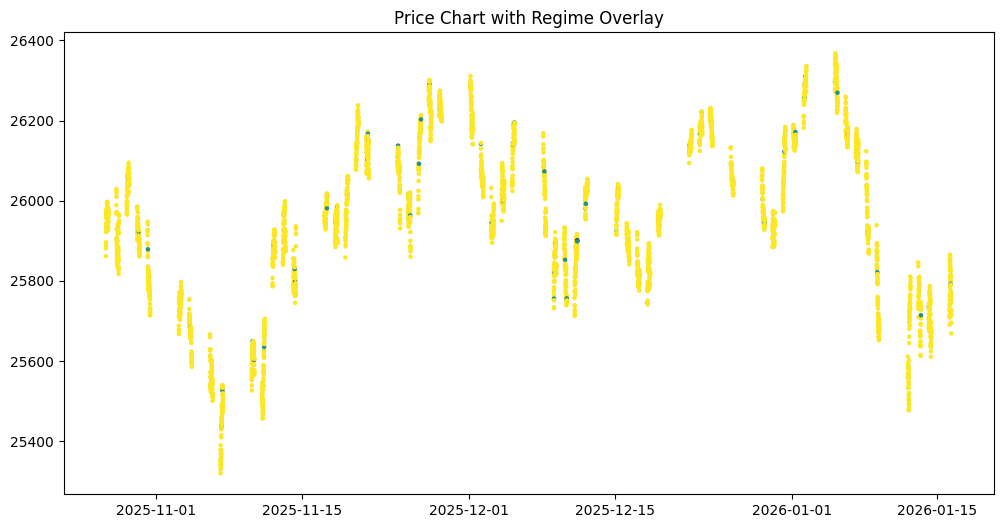

In [1]:
import pandas as pd
from hmmlearn import hmm
import matplotlib.pyplot as plt

#  Load feature dataset
df = pd.read_csv("../data/nifty_features_5min.csv", index_col=0, parse_dates=True)

#  CREATE missing feature(s) — MUST be here
df['Avg_IV'] = (df['IV_CE'] + df['IV_PE']) / 2

#  Select HMM features
features = ['Avg_IV', 'PCR_OI', 'Futures_Basis', 'Delta_CE']
X = df[features].dropna()

#  Train HMM on 70% data
train_size = int(len(X) * 0.7)
model = hmm.GaussianHMM(n_components=3, covariance_type="full", random_state=42)
model.fit(X.iloc[:train_size])

#  Predict regimes
df['Regime'] = model.predict(X)

#  Visualization
plt.figure(figsize=(12,6))
plt.scatter(df.index, df['Close'], c=df['Regime'], cmap='viridis', s=5)
plt.title("Price Chart with Regime Overlay")
plt.savefig("../plots/feature_importance01.png")
plt.show()

#  Save output
df.to_csv("../data/nifty_regimes_5min.csv")
